In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import explained_variance_score
from sklearn.metrics import r2_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import RobustScaler

from sklearn.pipeline import make_pipeline

from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

###Description of the variables in the base DataFrame

VARIABLE | DESCRIPTION | TYPE  
---------|-------------|-----  
**FECHA_CORTE** | Data cutoff date | Numeric
**UBIGEO** | Geographical Location Code denoted as 'DDppdd' (Department, Province, District) | Alphanumeric  
**YY** | Year, año de registro | Numeric  
**MM** | Month, mes de registro | Numeric  
**DY** | Day, día de registro | Numeric  
**HH** | Hour, hora promedio del registro | Numeric  
**TT** | Air Temperature 2 meters (temperatura del aire a 2 metros) - [°C] | Numeric  
**HR** | Relative Humidity (Humedad Relativa) - [%] | Numeric  
**RR** | Precipitation (precipitación) - [mm] | Numeric  
**PP** | Atmospheric pressure (presión atmosférica) - [hPa] | Numeric  
**FF** | Wind speed (velocidad del aire) - [m/s] | Numeric  
**DD** | Wind direction (dirección del aire) - [degrees] | Numeric  


In [2]:
# Reading the base dataset
df_base = pd.read_csv('IGP_EstacionEMA_2018-2024_Dataset.csv')
# The columns FECHA_CORTE and UBIGEO are removed because they are constant
df_base.drop(columns=["FECHA_CORTE","UBIGEO"],inplace=True)
df_base.head()

,YY,MM,DY,HH,TT,HR,RR,PP,FF,DD
0,2018,1,1,0,7.66098,89.51500,1.778,687.40333,2.97943,145.64165
1,2018,1,1,1,7.73552,90.29500,0.254,686.94167,1.70000,284.01833
2,2018,1,1,2,7.57108,91.00500,0.254,686.67667,1.65667,63.06462
3,2018,1,1,3,7.52045,89.73167,0.000,686.50000,1.13227,34.77467
4,2018,1,1,4,7.13343,88.88167,0.508,686.60333,0.64763,72.41817


### Description of variables in the auxiliary DataFrame of different wave irradiances

VARIABLE | DESCRIPTION | TYPE
---------|-------------|-----
**FECHA_CORTE**	| Data cutoff date |	Numeric
**UBIGEO**	| Geographical Location Code denoted as 'DDppdd' (Department, Province, District) | 	Alphanumeric
**year** |	Year, año de registro |	Numeric
**month** |	Month, mes de registro |	Numeric
**day** |	Day, dia de registro |	Numeric
**hour** | Hour, hora promedio del registro	| Numeric
**incide_LW_rad** |	Incident longwave irradiance (irradiancia incidente de onda larga) W m^{-2} |	Numeric
**emitte_LW_rad** | 	Emitted longwave irradiance (irradiancia emitida de onda larga) W m^{-2}	| Numeric
**direct_SW_rad** |	Direct shortwave irradiance (irradiancia directa de onda corta) W m^{-2}	| Numeric
**global_SW_rad** |	Global shortwave irrandiance (irradiancia glocal de onda corta) W m^{-2}	| Numeric
**diffus_SW_rad** |	Diffuse shortwave irradiance (irradiancia difusa de onda corta) W m^{-2}	| Numeric
**reflec_SW_rad** |	Reflected shortwave irradiance (irradiancia reflejada de onda corta) W m^{-2}	| Numeric

In [3]:
df_aux1 = pd.read_csv('IGP_EstacionBSRN_2021-2023_Dataset_0.csv')
df_aux1.drop(columns=["FECHA_CORTE","UBIGEO"],inplace=True)
df_aux1.head()

,year,month,day,hour,incide_LW_rad,emitte_LW_rad,direct_SW_rad,global_SW_rad,diffus_SW_rad,reflec_SW_rad
0,2021,1,1,0,352.05167,367.13500,-0.25327,0.0,0.0,0.0
1,2021,1,1,1,352.87167,364.62333,-0.20893,0.0,0.0,0.0
2,2021,1,1,2,345.94833,359.72500,-0.22720,0.0,0.0,0.0
3,2021,1,1,3,343.00833,357.59000,-0.15992,0.0,0.0,0.0
4,2021,1,1,4,341.39167,357.58333,-0.11268,0.0,0.0,0.0


**The columns of the base DataFrame are renamed to match the date names in the auxiliary DataFrame.**

This is done for two reasons:
1. The variables will be understandable without relying on the data dictionary.
2. A merge can be applied without issues because the column names match.

In [4]:
df_base.rename(columns={'YY': 'year', 'MM': 'month', 'DY': 'day', 'HH': 'hour'}, inplace=True)

In [5]:
df_final = df_base.merge(df_aux1, on=['year', 'month', 'day', 'hour'], how='inner')
print(df_final.shape)
df_final.head()

(26280, 16)


,year,month,day,hour,TT,HR,RR,PP,FF,DD,incide_LW_rad,emitte_LW_rad,direct_SW_rad,global_SW_rad,diffus_SW_rad,reflec_SW_rad
0,2021,1,1,0,10.21567,89.11500,0.000,686.42667,0.76495,137.41667,352.05167,367.13500,-0.25327,0.0,0.0,0.0
1,2021,1,1,1,9.46817,92.15333,2.540,686.20333,1.08187,212.86167,352.87167,364.62333,-0.20893,0.0,0.0,0.0
2,2021,1,1,2,8.41033,94.19000,2.794,686.09167,1.27178,124.28170,345.94833,359.72500,-0.22720,0.0,0.0,0.0
3,2021,1,1,3,7.83418,94.81167,2.286,686.16167,0.72635,137.59570,343.00833,357.59000,-0.15992,0.0,0.0,0.0
4,2021,1,1,4,7.82893,94.77833,1.270,686.47667,0.99590,304.42042,341.39167,357.58333,-0.11268,0.0,0.0,0.0


In [6]:
df_final=df_final.dropna()

In [7]:
df_final.isnull().sum()

,0
year,0
month,0
day,0
hour,0
TT,0
HR,0
RR,0
PP,0
FF,0
DD,0


In [8]:
df1=df_final.drop(columns=['RR'])

In [9]:
df1

,year,month,day,hour,TT,HR,PP,FF,DD,incide_LW_rad,emitte_LW_rad,direct_SW_rad,global_SW_rad,diffus_SW_rad,reflec_SW_rad
0,2021,1,1,0,10.21567,89.11500,686.42667,0.76495,137.41667,352.05167,367.13500,-0.25327,0.0,0.0,0.0
1,2021,1,1,1,9.46817,92.15333,686.20333,1.08187,212.86167,352.87167,364.62333,-0.20893,0.0,0.0,0.0
2,2021,1,1,2,8.41033,94.19000,686.09167,1.27178,124.28170,345.94833,359.72500,-0.22720,0.0,0.0,0.0
3,2021,1,1,3,7.83418,94.81167,686.16167,0.72635,137.59570,343.00833,357.59000,-0.15992,0.0,0.0,0.0
4,2021,1,1,4,7.82893,94.77833,686.47667,0.99590,304.42042,341.39167,357.58333,-0.11268,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25916,2023,12,16,20,9.50950,88.70500,687.55833,2.70477,124.55708,330.86333,362.72333,-0.10637,0.0,0.0,0.0
25917,2023,12,16,21,9.25217,88.74000,687.82000,2.54373,116.06547,318.85000,360.35833,-0.12065,0.0,0.0,0.0
25918,2023,12,16,22,8.88700,90.57000,688.28000,1.38287,141.80000,296.66167,355.66500,-0.10048,0.0,0.0,0.0
25919,2023,12,16,23,7.44867,95.69667,687.91667,2.05465,270.97500,277.11833,349.23000,-0.40282,0.0,0.0,0.0


In [10]:
shift=1
df1=df1.iloc[:-1*shift]
df1

,year,month,day,hour,TT,HR,PP,FF,DD,incide_LW_rad,emitte_LW_rad,direct_SW_rad,global_SW_rad,diffus_SW_rad,reflec_SW_rad
0,2021,1,1,0,10.21567,89.11500,686.42667,0.76495,137.41667,352.05167,367.13500,-0.25327,0.0,0.0,0.0
1,2021,1,1,1,9.46817,92.15333,686.20333,1.08187,212.86167,352.87167,364.62333,-0.20893,0.0,0.0,0.0
2,2021,1,1,2,8.41033,94.19000,686.09167,1.27178,124.28170,345.94833,359.72500,-0.22720,0.0,0.0,0.0
3,2021,1,1,3,7.83418,94.81167,686.16167,0.72635,137.59570,343.00833,357.59000,-0.15992,0.0,0.0,0.0
4,2021,1,1,4,7.82893,94.77833,686.47667,0.99590,304.42042,341.39167,357.58333,-0.11268,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25915,2023,12,16,19,9.07850,90.48000,687.37500,3.22438,274.75333,343.59667,362.73333,-0.13072,0.0,0.0,0.0
25916,2023,12,16,20,9.50950,88.70500,687.55833,2.70477,124.55708,330.86333,362.72333,-0.10637,0.0,0.0,0.0
25917,2023,12,16,21,9.25217,88.74000,687.82000,2.54373,116.06547,318.85000,360.35833,-0.12065,0.0,0.0,0.0
25918,2023,12,16,22,8.88700,90.57000,688.28000,1.38287,141.80000,296.66167,355.66500,-0.10048,0.0,0.0,0.0


In [11]:
df2=df_final['RR']
df2

,RR
0,0.000
1,2.540
2,2.794
3,2.286
4,1.270
...,...
25916,0.000
25917,0.000
25918,0.000
25919,0.000


In [12]:
df2=df2.drop(df2.index[0:shift])
df2

,RR
1,2.540
2,2.794
3,2.286
4,1.270
5,0.000
...,...
25916,0.000
25917,0.000
25918,0.000
25919,0.000


In [13]:
df_total = pd.concat([df1.reset_index(drop=True), df2.reset_index(drop=True)], axis=1)
df_total

,year,month,day,hour,TT,HR,PP,FF,DD,incide_LW_rad,emitte_LW_rad,direct_SW_rad,global_SW_rad,diffus_SW_rad,reflec_SW_rad,RR
0,2021,1,1,0,10.21567,89.11500,686.42667,0.76495,137.41667,352.05167,367.13500,-0.25327,0.0,0.0,0.0,2.540
1,2021,1,1,1,9.46817,92.15333,686.20333,1.08187,212.86167,352.87167,364.62333,-0.20893,0.0,0.0,0.0,2.794
2,2021,1,1,2,8.41033,94.19000,686.09167,1.27178,124.28170,345.94833,359.72500,-0.22720,0.0,0.0,0.0,2.286
3,2021,1,1,3,7.83418,94.81167,686.16167,0.72635,137.59570,343.00833,357.59000,-0.15992,0.0,0.0,0.0,1.270
4,2021,1,1,4,7.82893,94.77833,686.47667,0.99590,304.42042,341.39167,357.58333,-0.11268,0.0,0.0,0.0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19785,2023,12,16,19,9.07850,90.48000,687.37500,3.22438,274.75333,343.59667,362.73333,-0.13072,0.0,0.0,0.0,0.000
19786,2023,12,16,20,9.50950,88.70500,687.55833,2.70477,124.55708,330.86333,362.72333,-0.10637,0.0,0.0,0.0,0.000
19787,2023,12,16,21,9.25217,88.74000,687.82000,2.54373,116.06547,318.85000,360.35833,-0.12065,0.0,0.0,0.0,0.000
19788,2023,12,16,22,8.88700,90.57000,688.28000,1.38287,141.80000,296.66167,355.66500,-0.10048,0.0,0.0,0.0,0.000


In [14]:
df_total['rain_exists'] = df_total['RR'].apply(lambda x: 0 if x <= 0.0 else 1)
print(df_total.groupby('month')['rain_exists'].value_counts())
df_total.drop(columns='rain_exists', inplace=True)

selected_months = [12, 1, 2, 3]
df_total = df_total[df_total['month'].isin(selected_months)]

df_total['hour_sin'] = np.sin(2 * np.pi * df_total['hour'] / 24)
df_total['hour_cos'] = np.cos(2 * np.pi * df_total['hour'] / 24)

print(df_total.shape)

df_total.drop(columns=['year','day','month','hour'],inplace=True)

month  rain_exists
1      0              1689
       1               207
2      0              1202
       1               129
3      0              1617
       1               226
4      0              1439
       1                92
5      0              1429
       1                69
6      0              1653
       1                23
7      0              1687
       1                 3
8      0              1554
       1                21
9      0              1644
       1                55
10     0              1621
       1                86
11     0              1606
       1               125
12     0              1463
       1               150
Name: count, dtype: int64
(6683, 18)


                    PC1       PC2
emitte_LW_rad  0.377573  0.011588
reflec_SW_rad  0.364675  0.195692
global_SW_rad  0.363550  0.195551
TT             0.350811  0.205095
hour_cos       0.345539  0.049408
HR             0.331139  0.193633
diffus_SW_rad  0.318289  0.134478
direct_SW_rad  0.270905  0.188095
DD             0.174649  0.103771
FF             0.144484  0.462591


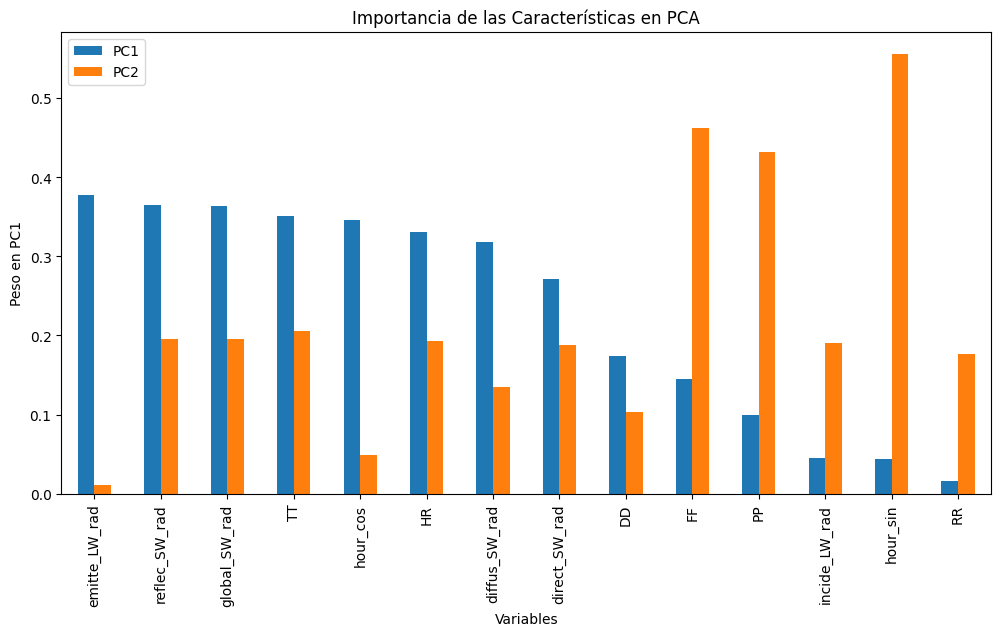

In [15]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_total)

pca = PCA(n_components=2)
pca.fit(df_scaled)

# Obtain the importance of each feature
importance = np.abs(pca.components_[:2])

# Convert into a DataFrame for visualization
columns = df_total.columns
importance_df = pd.DataFrame(importance.T, index=columns, columns=['PC1', 'PC2'])

# Sort by relevance in the first principal component
importance_df = importance_df.sort_values(by='PC1', ascending=False)

# Display the most influential variables
print(importance_df.head(10))

# Plot the feature importance
importance_df.plot(kind='bar', figsize=(12, 6))
plt.title('Importancia de las Características en PCA')
plt.xlabel('Variables')
plt.ylabel('Peso en PC1')
plt.show()

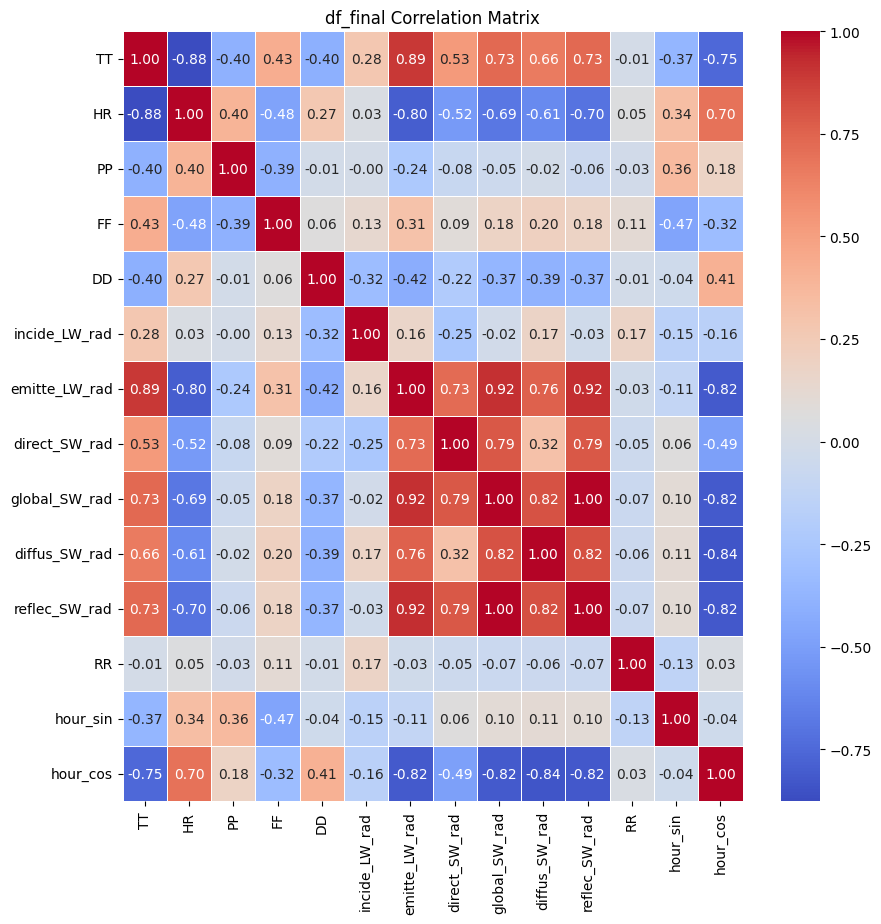

In [16]:
# Calculate the correlation matrix of df_final
corr_matrix = df_total.corr()

# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

# Show the plot
plt.title('df_final Correlation Matrix')
plt.show()

In [17]:
from sklearn.ensemble import RandomForestRegressor
X=df_total.drop(columns=['RR'])
y=df_total['RR']
modelo = RandomForestRegressor()
modelo.fit(X, y)

importancia = modelo.feature_importances_
pd.Series(importancia, index=X.columns).sort_values(ascending=False)

,0
incide_LW_rad,0.208008
DD,0.133802
FF,0.129177
emitte_LW_rad,0.093234
PP,0.091442
direct_SW_rad,0.076884
TT,0.075675
HR,0.065305
hour_sin,0.050430
global_SW_rad,0.023762


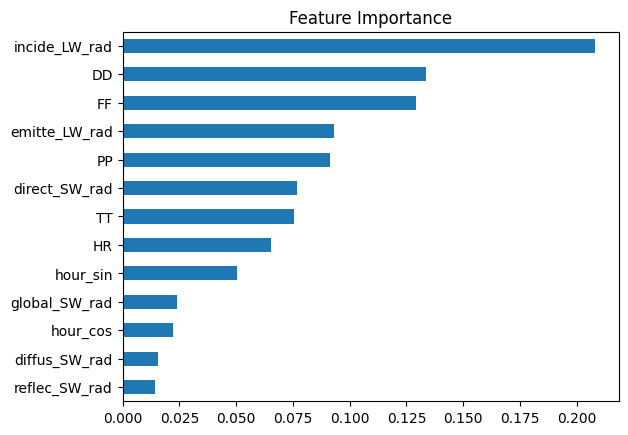

In [18]:
importancia = pd.Series(modelo.feature_importances_, index=X.columns)
importancia.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [19]:
columns_drop=['hour_cos','hour_sin','global_SW_rad','reflec_SW_rad','diffus_SW_rad']

In [20]:
df_total.drop(columns=columns_drop, inplace=True)

In [21]:
df_total

,TT,HR,PP,FF,DD,incide_LW_rad,emitte_LW_rad,direct_SW_rad,RR
0,10.21567,89.11500,686.42667,0.76495,137.41667,352.05167,367.13500,-0.25327,2.540
1,9.46817,92.15333,686.20333,1.08187,212.86167,352.87167,364.62333,-0.20893,2.794
2,8.41033,94.19000,686.09167,1.27178,124.28170,345.94833,359.72500,-0.22720,2.286
3,7.83418,94.81167,686.16167,0.72635,137.59570,343.00833,357.59000,-0.15992,1.270
4,7.82893,94.77833,686.47667,0.99590,304.42042,341.39167,357.58333,-0.11268,0.000
...,...,...,...,...,...,...,...,...,...
19785,9.07850,90.48000,687.37500,3.22438,274.75333,343.59667,362.73333,-0.13072,0.000
19786,9.50950,88.70500,687.55833,2.70477,124.55708,330.86333,362.72333,-0.10637,0.000
19787,9.25217,88.74000,687.82000,2.54373,116.06547,318.85000,360.35833,-0.12065,0.000
19788,8.88700,90.57000,688.28000,1.38287,141.80000,296.66167,355.66500,-0.10048,0.000


##The linear regression model is trained.
For this training, only the rows where precipitation is greater than 0 are considered, since the model is intended to be used after a classification step.

In [22]:
# Splitting the dataset into features (X) and target (y)
df_reg_lineal = df_total.copy()
df_cl = df_total.copy()
df_smote = df_total.copy()
df_reg_lineal = df_reg_lineal[df_reg_lineal['RR'] > 0]

y = df_reg_lineal['RR']
X = df_reg_lineal.drop(['RR'], axis=1)

test_size = 0.20
seed = 55
x_train,x_test,y_train,y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Training set size:", len(y_train))
print("Test set size:", len(y_test))

Training set size: 569
Test set size: 143


In [23]:
algos = []

algos.append(('LinearReg', LinearRegression()))
algos.append(('Ridge', Ridge()))
algos.append(('Lasso', Lasso()))
algos.append(('ElasticNet', ElasticNet()))
algos.append(('KNN_5', KNeighborsRegressor(n_neighbors=5)))
algos.append(('KNN_10', KNeighborsRegressor(n_neighbors=10)))
algos.append(('RegTrees', DecisionTreeRegressor()))
algos.append(('RegTrees_10', DecisionTreeRegressor(max_depth=10)))

In [24]:
# Each ML algorithm is evaluated using a 10-fold cross-validation strategy.
results = []
names = []

seed = 42
kfold = KFold(n_splits=10, random_state=seed, shuffle= True)

for algoname, algo in algos:
    cv_results = cross_val_score(algo, x_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
    results.append(cv_results)
    names.append(algoname)
    print("{}: {} ({})".format(algoname, cv_results.mean(), cv_results.std()))

LinearReg: -1.3078637060386655 (0.5254223770087917)
Ridge: -1.3078364934076532 (0.525449742146039)
Lasso: -1.3507685952664696 (0.5494053115734017)
ElasticNet: -1.356899053593522 (0.5592052473033787)
KNN_5: -1.6316786834385966 (0.6108078463743437)
KNN_10: -1.440242571849624 (0.5517653411448272)
RegTrees: -2.5915078738095234 (0.5280301755100342)
RegTrees_10: -2.335367816673325 (0.3566922595397729)


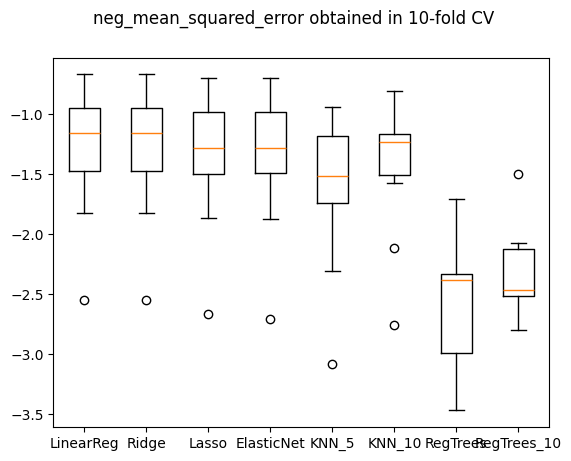

In [25]:
fig = plt.figure()
fig.suptitle('neg_mean_squared_error obtained in 10-fold CV')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

The Ridge algorithm is chosen for training the model because it shows a lower absolute MSE compared to the models trained with the other algorithms.

In [26]:
model = Ridge()
model.fit(x_train, y_train)
y_predicted = model.predict(x_test)

print("Mean squared error:", mean_squared_error(y_test, y_predicted))
print("Mean absolute error:", mean_absolute_error(y_test, y_predicted))
print("Explained variance score:",explained_variance_score(y_test, y_predicted) )
print("R2 score:", r2_score(y_test, y_predicted))

Mean squared error: 1.8499222827929134
Mean absolute error: 0.7659956843832113
Explained variance score: -0.02380253434218149
R2 score: -0.026137900402035452


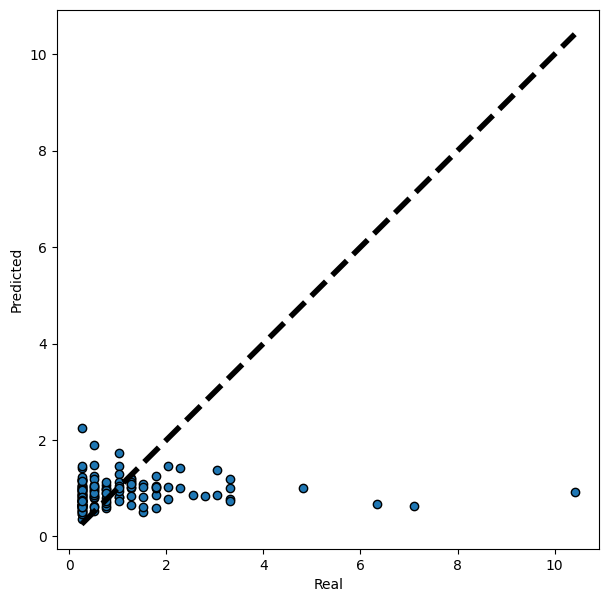

In [27]:
fig, ax = plt.subplots( figsize=[7,7])
ax.scatter(y_test, y_predicted, edgecolors=(0, 0, 0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Real')
ax.set_ylabel('Predicted')
plt.show()

##The model is trained again, this time using Pipelines
This is done in order to test whether better results can be obtained with scalers.

In [28]:
pipelines = []

pipelines.append(('LinearReg', make_pipeline(Normalizer(), LinearRegression())))
pipelines.append(('Ridge', make_pipeline(StandardScaler(), Ridge())))
pipelines.append(('Lasso', make_pipeline(StandardScaler(), Lasso())))
pipelines.append(('ElasticNet', make_pipeline(Normalizer(), ElasticNet())))
pipelines.append(('KNN_5', make_pipeline(MinMaxScaler(), KNeighborsRegressor(n_neighbors=5))))
pipelines.append(('KNN_10', make_pipeline(MinMaxScaler(), KNeighborsRegressor(n_neighbors=10))))
pipelines.append(('RegTrees', make_pipeline(RobustScaler(), DecisionTreeRegressor())))
pipelines.append(('RegTrees_10', make_pipeline(RobustScaler(), DecisionTreeRegressor(max_depth=10))))

In [29]:
results = []
names = []

seed = 55
kfold = KFold(n_splits=10, random_state=seed, shuffle= True)

## Evalua cada algoritmo
for pipelinename, pipeline in pipelines:
    cv_results = cross_val_score(pipeline, x_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
    results.append(cv_results)
    names.append(pipelinename)
    print("{}: {} ({})".format(pipelinename, cv_results.mean(), cv_results.std()))

LinearReg: -1.3198851329231518 (0.5483147368924632)
Ridge: -1.3129530136356498 (0.553190630157336)
Lasso: -1.3527225955040807 (0.5815019851708726)
ElasticNet: -1.3527225955040807 (0.5815019851708726)
KNN_5: -1.5437291463458647 (0.5662076085463243)
KNN_10: -1.3834660462243107 (0.5769141979897152)
RegTrees: -2.8427423135338343 (1.0005198301419997)
RegTrees_10: -2.3165610775806877 (0.9087677762251595)


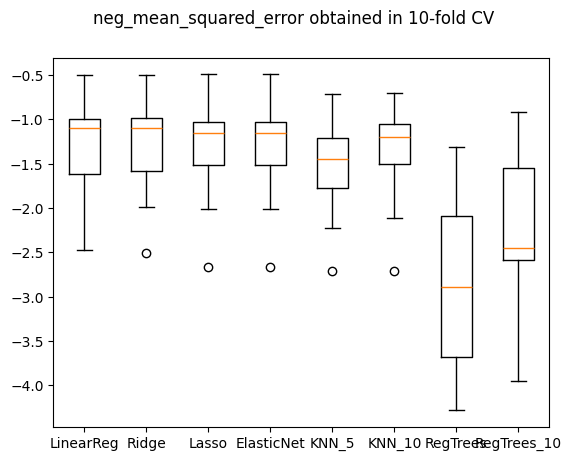

In [30]:
fig = plt.figure()
fig.suptitle('neg_mean_squared_error obtained in 10-fold CV')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

The Ridge() algorithm with StandardScaler() is chosen because it shows the lowest absolute MSE.

In [31]:
pipeline = make_pipeline(StandardScaler(), Ridge())
pipeline.fit(x_train, y_train)

y_predicted = pipeline.predict(x_test)

print("Mean squared error:", mean_squared_error(y_test, y_predicted))
print("Mean absolute error:", mean_absolute_error(y_test, y_predicted))
print("Explained variance score:",explained_variance_score(y_test, y_predicted) )
print("R2 score:", r2_score(y_test, y_predicted))

Mean squared error: 1.849239613261154
Mean absolute error: 0.7662247928322877
Explained variance score: -0.023429732470338083
R2 score: -0.025759228775392495


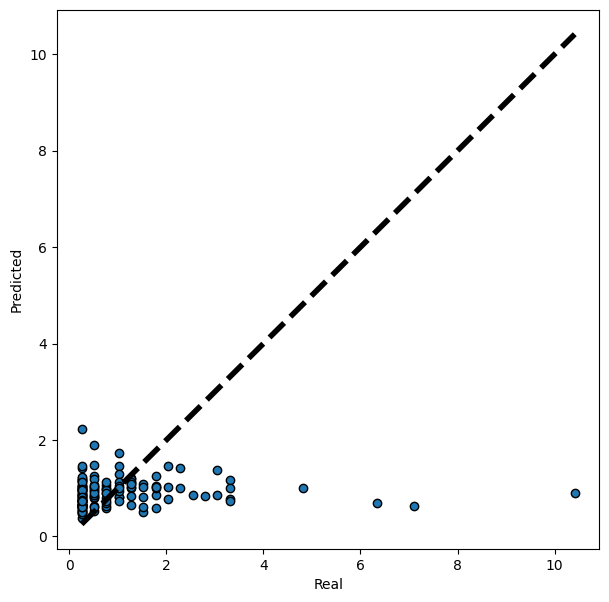

In [32]:
fig, ax = plt.subplots(figsize=[7,7])
ax.scatter(y_test, y_predicted, edgecolors=(0, 0, 0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Real')
ax.set_ylabel('Predicted')
plt.show()

##The classification model that decides whether it will rain or not is trained.
The purpose of this is that, in case of rain, these data will be passed to the linear regression model to predict the exact depth on the ground caused by the precipitation.

In [33]:
df_cl['rain_exists'] = df_cl['RR'].apply(lambda x: 0 if x <= 0.0 else 1)
df_cl.drop(columns='RR', inplace=True)

X = df_cl.drop(['rain_exists'], axis=1)
y = df_cl['rain_exists']

test_size = 0.20
seed = 55
x_train,x_test,y_train,y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)

print("Train set size:", len(y_train))
print("Test set size:", len(y_test))

Train set size: 5346
Test set size: 1337


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

algos = []
algos.append(('LogReg', LogisticRegression( solver='liblinear', class_weight='balanced')))
algos.append(('5NN', KNeighborsClassifier( n_neighbors=5)))
algos.append(('10NN', KNeighborsClassifier( n_neighbors=10)))
algos.append(('CART_none', DecisionTreeClassifier(max_depth=None ,class_weight='balanced')))
algos.append(('CART_20', DecisionTreeClassifier(max_depth=20,class_weight='balanced')))
algos.append(('XGBClassifier', XGBClassifier()))

In [35]:
results = []
names = []

seed = 7
kfold = KFold(n_splits=10, random_state=seed, shuffle= True)

for algoname, algo in algos:
    cv_results = cross_val_score(algo, x_train, y_train, cv=kfold, scoring='balanced_accuracy')
    results.append(cv_results)
    names.append(algoname)
    print("{}: {} ({})".format(algoname, cv_results.mean(), cv_results.std()))

LogReg: 0.741510440150613 (0.013711885376240575)
5NN: 0.5936188108484204 (0.018578580823469394)
10NN: 0.5452009029876567 (0.01761392887456834)
CART_none: 0.639865047507859 (0.031468341956513574)
CART_20: 0.649746913916728 (0.017247626330672002)
XGBClassifier: 0.637341341633103 (0.019134778183281204)


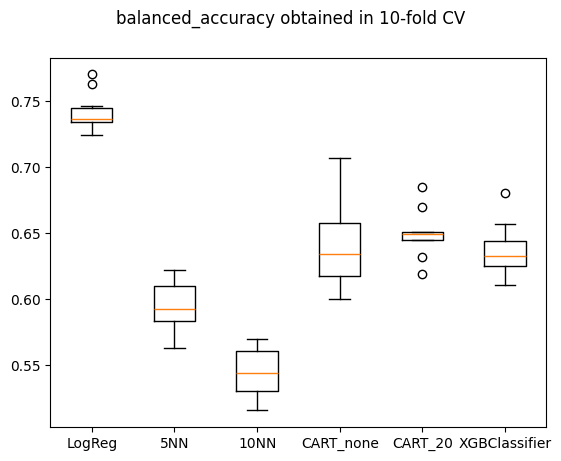

In [36]:
fig = plt.figure()
fig.suptitle('balanced_accuracy obtained in 10-fold CV')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

##The results are now displayed
Evaluated with LogisticRegression and DecisionTreeClassifier (max_depth=20).

In [37]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import jaccard_score

model = LogisticRegression(solver='liblinear' , class_weight = 'balanced')
model.fit(x_train, y_train)

y_predicted = model.predict(x_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predicted))

print("\nClassification Report on the Validation Set: \n")
print(classification_report(y_test, y_predicted))

Balanced Accuracy score: 0.755904885379221

Confusion Matrix:
[[822 373]
 [ 25 117]]

Classification Report on the Validation Set: 

              precision    recall  f1-score   support

           0       0.97      0.69      0.81      1195
           1       0.24      0.82      0.37       142

    accuracy                           0.70      1337
   macro avg       0.60      0.76      0.59      1337
weighted avg       0.89      0.70      0.76      1337



Although the precision for predicting rain is low, the high recall is advantageous and fulfills the goal of the project.

In [38]:
model = DecisionTreeClassifier(max_depth=20,class_weight='balanced')
model.fit(x_train, y_train)

y_predicted = model.predict(x_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

print("\Confusion Matrix:")
print(confusion_matrix(y_test, y_predicted))

print("\nClassification Report on the Validation Set: \n")
print(classification_report(y_test, y_predicted))

Balanced Accuracy score: 0.6702634215333845
\Confusion Matrix:
[[1097   98]
 [  82   60]]

Classification Report on the Validation Set: 

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1195
           1       0.38      0.42      0.40       142

    accuracy                           0.87      1337
   macro avg       0.66      0.67      0.66      1337
weighted avg       0.87      0.87      0.87      1337



The XGBClassifier algorithm shows higher precision in predicting rain, but its recall is only about 40%, which is not particularly beneficial.

#The hybrid model is trained
An initial split of the dataset is performed to separate the predictor variables (X) from the target variables. In this case, two targets are defined:
1. y_cl: a binary variable indicating whether it rained or not (classification stage).

2. y_reg: a continuous variable representing the amount of rainfall, log-transformed to mitigate the concentration of values close to zero (regression stage).

This approach allows the problem to be addressed in a hierarchical manner, where the occurrence of rainfall is predicted first, and only in cases where rainfall is expected, its magnitude is subsequently estimated.


In [39]:
df_total['rain_exists'] = df_total['RR'].apply(lambda x: 0 if x <= 0.0 else 1)
df_total['logRR'] = np.log1p(df_total['RR'])

X = df_total.drop(columns=['RR', 'rain_exists','logRR'])
y_cl = df_total['rain_exists']
y_reg = df_total['logRR']

X_train, X_test, y_cl_train, y_cl_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cl, y_reg, test_size=0.30, random_state=42, stratify=y_cl
)

clf = LogisticRegression(solver='liblinear' , class_weight = 'balanced')
clf.fit(X_train, y_cl_train)

y_cl_pred = clf.predict(X_test)

print("Classification:")
print("Balanced Accuracy:", balanced_accuracy_score(y_cl_test, y_cl_pred))

# Filter only the cases where rain was predicted
X_reg_test = X_test[y_cl_pred == 1]
y_reg_test_true = y_reg_test[y_cl_pred == 1]

# Note: the regressor is trained on y_reg_train_full, restricted to cases with actual rainfall.
X_reg_train = X_train[y_cl_train == 1]
y_reg_train = y_reg_train[y_cl_train == 1]

print("Train set size:", len(X_reg_train))
print("Test set size:", len(X_reg_test))

# The regression model is trained exclusively on instances with non-zero rainfall.
reg = make_pipeline(StandardScaler(), Ridge())
reg.fit(X_reg_train, y_reg_train)

if not X_reg_test.empty:

    y_reg_pred = reg.predict(X_reg_test)
    y_reg_pred = np.expm1(y_reg_pred)
    y_reg_test_true = np.expm1(y_reg_test_true)
    print("\nRegression (applied only when rain is predicted)")
    print("MAE:", mean_absolute_error(y_reg_test_true, y_reg_pred))
    print("MSE:", mean_squared_error(y_reg_test_true, y_reg_pred))
    print("R²:", r2_score(y_reg_test_true, y_reg_pred))
else:
    print("\nNo cases with predicted rainfall were found in the test set.")

df_pred = pd.DataFrame({
    'y_cl_pred': y_cl_pred
}, index=X_test.index)

df_pred['y_reg_pred'] = 0.0

if not X_reg_test.empty:
# Insert regression outputs into the instances where rain was classified as present
    df_pred.loc[y_cl_pred == 1, 'y_reg_pred'] = y_reg_pred

y_reg_pred_full = df_pred['y_reg_pred']
y_reg_test = np.expm1(y_reg_test)
print("\nClassification + regression:")
print("MAE:", mean_absolute_error(y_reg_test, y_reg_pred_full))
print("MSE:", mean_squared_error(y_reg_test, y_reg_pred_full))
print("R²:", r2_score(y_reg_test, y_reg_pred_full))

Classification:
Balanced Accuracy: 0.7520129202607012
Train set size: 498
Test set size: 765

Regression (applied only when rain is predicted)
MAE: 0.7422200376286493
MSE: 0.8181143067848059
R²: -0.5339591492348366

Classification + regression:
MAE: 0.2999133809406069
MSE: 0.3560385380001877
R²: -0.38737458018210247


The results obtained were not as expected, since the Logistic Regression algorithm had the highest recall when predicting class 1. Therefore, it was anticipated that combining the Logistic Regression classifier with a Ridge regression model (with a StandardScaler) would yield a higher percentage of data representation. However, in this case, the score turned out to be below zero, which indicates that the model performs very poorly (worse than using the mean as a prediction). For this reason, it was decided to discard it and instead use the second-best algorithm.

In [40]:
df_total['rain_exists'] = df_total['RR'].apply(lambda x: 0 if x <= 0.0 else 1)
df_total['logRR'] = np.log1p(df_total['RR'])

X = df_total.drop(columns=['RR', 'rain_exists','logRR'])
y_cl = df_total['rain_exists']
y_reg = df_total['logRR']

X_train, X_test, y_cl_train, y_cl_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cl, y_reg, test_size=0.30, random_state=42, stratify=y_cl
)

clf = DecisionTreeClassifier(max_depth=20, class_weight='balanced')
clf.fit(X_train, y_cl_train)

y_cl_pred = clf.predict(X_test)

print("Classification:")
print("Balanced Accuracy:", balanced_accuracy_score(y_cl_test, y_cl_pred))

X_reg_test = X_test[y_cl_pred == 1]
y_reg_test_true = y_reg_test[y_cl_pred == 1]

X_reg_train = X_train[y_cl_train == 1]
y_reg_train = y_reg_train[y_cl_train == 1]

print("Train set size:", len(X_reg_train))
print("Test set size:", len(X_reg_test))

reg = make_pipeline(StandardScaler(), Ridge())
reg.fit(X_reg_train, y_reg_train)

if not X_reg_test.empty:

    y_reg_pred = reg.predict(X_reg_test)
    y_reg_pred = np.expm1(y_reg_pred)
    y_reg_test_true = np.expm1(y_reg_test_true)
    print("\nRegression (applied only when rain is predicted):")
    print("MAE:", mean_absolute_error(y_reg_test_true, y_reg_pred))
    print("MSE:", mean_squared_error(y_reg_test_true, y_reg_pred))
    print("R²:", r2_score(y_reg_test_true, y_reg_pred))
else:
    print("\nNo cases with predicted rainfall were found in the test set.")

df_pred = pd.DataFrame({
    'y_cl_pred': y_cl_pred
}, index=X_test.index)

df_pred['y_reg_pred'] = 0.0

if not X_reg_test.empty:
    df_pred.loc[y_cl_pred == 1, 'y_reg_pred'] = y_reg_pred

y_reg_pred_full = df_pred['y_reg_pred']
y_reg_test = np.expm1(y_reg_test)
print("\nClassification + regression:")
print("MAE:", mean_absolute_error(y_reg_test, y_reg_pred_full))
print("MSE:", mean_squared_error(y_reg_test, y_reg_pred_full))
print("R²:", r2_score(y_reg_test, y_reg_pred_full))

Classification:
Balanced Accuracy: 0.6503741448676403
Train set size: 498
Test set size: 239

Regression (applied only when rain is predicted):
MAE: 0.7440949947130745
MSE: 1.092349402135498
R²: -0.13876453552153256

Classification + regression:
MAE: 0.1486188048560722
MSE: 0.2668039536710145
R²: -0.03965437363708557


The DecisionTreeClassifier with max_depth = 20 was selected, as it provides a better data representation than Logistic Regression. However, it still performs worse than simply predicting the average

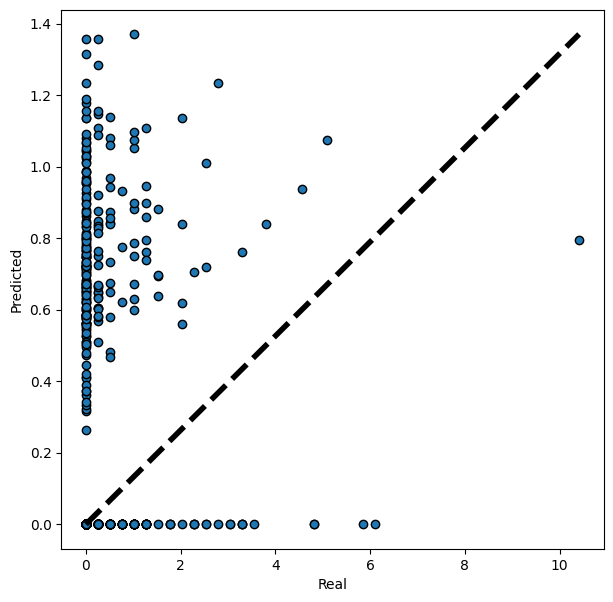

In [41]:
fig, ax = plt.subplots(figsize=[7,7])
ax.scatter(y_reg_test, y_reg_pred_full, edgecolors=(0, 0, 0))
ax.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_pred_full.min(), y_reg_pred_full.max()], 'k--', lw=4)
ax.set_xlabel('Real')
ax.set_ylabel('Predicted')
plt.show()

#Model with Balanced Classes using SMOTE

Given the low performance of the hybrid classification-regression model, a new classification model is proposed with a focus on improving the detection of moderate or heavy rainfall cases.

To address the class imbalance in the dataset, the SMOTE (Synthetic Minority Over-sampling Technique) method is applied. SMOTE generates synthetic samples of the minority class (days with moderate or heavy rainfall) by interpolating between similar observations in the feature space.

With this procedure, the classifier is trained on a more balanced dataset, which:

1. Reduces bias toward the majority class (days without rain or with light rain).

2. Increases the model’s ability to learn patterns associated with significant rainfall.

3. Improves critical metrics such as recall and balanced accuracy.

For simplification, rainfall intensity is defined into two levels:

Class 0 → No rain or light rain.

Class 1 → Moderate or heavy rain.

In [42]:
print(df_smote['RR'].value_counts())
bins = [0, 2.5, np.inf]
labels = [0, 1]
df_smote['rain_intensity'] = pd.cut(df_smote['RR'], bins=bins, labels=labels, right=False)
df_smote.drop(columns='RR', inplace=True)

RR
0.000     5971
0.254      313
0.508      111
0.762       59
1.016       51
1.270       37
1.524       20
1.778       20
2.032       17
2.794       13
2.286       12
2.540       12
3.302       10
3.810        6
3.556        5
3.048        5
4.826        4
4.064        2
5.080        2
4.572        2
7.112        1
6.096        1
10.414       1
6.604        1
5.842        1
8.128        1
5.588        1
6.350        1
7.874        1
4.318        1
6.858        1
Name: count, dtype: int64


In [43]:
print(df_smote['rain_intensity'].value_counts())

rain_intensity
0    6611
1      72
Name: count, dtype: int64


A balanced training set is prepared for a binary classification problem on the variable rain_intensity, which exhibits class imbalance. First, the dataset is split into training and test sets before applying any balancing technique. Then, a manual undersampling of the majority class is performed to obtain a more balanced dataset. Finally, SMOTE (Synthetic Minority Over-sampling Technique) is applied to generate synthetic samples of the minority class, while avoiding the excessive creation of artificial data by reducing the dominance of the majority class beforehand.

In [44]:
from collections import Counter

X = df_smote.drop('rain_intensity', axis=1)
y = df_smote['rain_intensity']

x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.20, random_state=42)

df_train = x_train.copy()
df_train['rain_intensity'] = y_train

df_0 = df_train[df_train['rain_intensity'] == 0].sample(n=3700, random_state=42)
df_1 = df_train[df_train['rain_intensity'] == 1]

df_train_bal = pd.concat([df_0, df_1], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

x_train = df_train_bal.drop('rain_intensity', axis=1)
y_train = df_train_bal['rain_intensity']

print("Train data distribution:")
print(Counter(y_train))
print("Test data distribution:")
print(Counter(y_test))

Train data distribution:
Counter({0: 3700, 1: 58})
Test data distribution:
Counter({0: 1323, 1: 14})


In [45]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='not majority', random_state=42)

x_train, y_train = smote.fit_resample(x_train, y_train)

print("Train data distribution after SMOTE:")
print(Counter(y_train))

Train data distribution after SMOTE:
Counter({0: 3700, 1: 3700})


In [46]:
algos = []
algos.append(('LogReg', LogisticRegression( solver='liblinear', class_weight='balanced')))
algos.append(('5NN', KNeighborsClassifier( n_neighbors=5)))
algos.append(('10NN', KNeighborsClassifier( n_neighbors=10)))
algos.append(('CART_none', DecisionTreeClassifier(max_depth=None, class_weight='balanced')))
algos.append(('CART_20', DecisionTreeClassifier(max_depth=20, class_weight='balanced')))
algos.append(('XGBClassifier', XGBClassifier()))

In [47]:
results = []
names = []

seed = 7
kfold = KFold(n_splits=10, random_state=seed, shuffle= True)

for algoname, algo in algos:
    cv_results = cross_val_score(algo, x_train, y_train, cv=kfold, scoring='balanced_accuracy')
    results.append(cv_results)
    names.append(algoname)
    print("{}: {} ({})".format(algoname, cv_results.mean(), cv_results.std()))

LogReg: 0.802649723098914 (0.016518372274534326)
5NN: 0.9195117177087099 (0.009846267750483938)
10NN: 0.9069410854547588 (0.011237779344545213)
CART_none: 0.9469029721255156 (0.00727649169481461)
CART_20: 0.9468362049281195 (0.007112455637440949)
XGBClassifier: 0.9756028090306426 (0.005700354922848752)


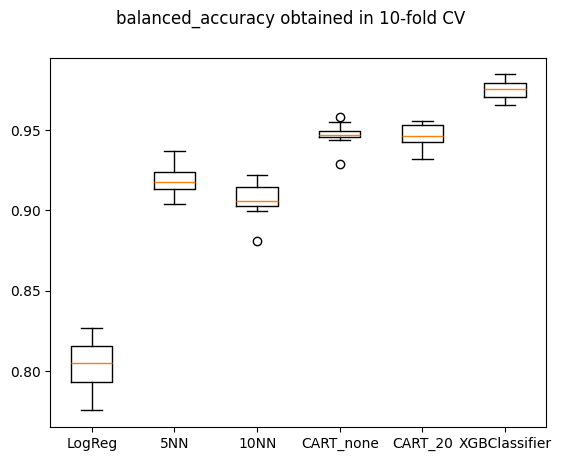

In [48]:
fig = plt.figure()
fig.suptitle('balanced_accuracy obtained in 10-fold CV')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

The LogisticRegression algorithm was selected because it achieves the highest balanced accuracy. Additionally, it provides the best prediction for cases of moderate or heavy rainfall (recall = 0.86), which is the most critical outcome to predict. Missing actual moderate or heavy rainfall events (false negatives) carries a higher cost than issuing a false alarm, making it a priority to maximize recall for this class.

In [49]:
model = LogisticRegression(solver='liblinear', class_weight='balanced')
model.fit(x_train, y_train)

y_predicted = model.predict(x_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predicted))

print("\nClassification Report on the Validation Set: \n")
print(classification_report(y_test, y_predicted))

Balanced Accuracy score: 0.8057445200302342

Confusion Matrix:
[[998 325]
 [  2  12]]

Classification Report on the Validation Set: 

              precision    recall  f1-score   support

           0       1.00      0.75      0.86      1323
           1       0.04      0.86      0.07        14

    accuracy                           0.76      1337
   macro avg       0.52      0.81      0.46      1337
weighted avg       0.99      0.76      0.85      1337



A model using the XGBClassifier algorithm was trained for comparison with the previous model. It showed lower balanced accuracy, and therefore the first model was chosen.

In [50]:
model = XGBClassifier()
model.fit(x_train, y_train)

y_predicted = model.predict(x_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predicted))

print("\nClassification Report on the Validation Set: \n")
print(classification_report(y_test, y_predicted))

Balanced Accuracy score: 0.7269463340891913

Confusion Matrix:
[[1262   61]
 [   7    7]]

Classification Report on the Validation Set: 

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1323
           1       0.10      0.50      0.17        14

    accuracy                           0.95      1337
   macro avg       0.55      0.73      0.57      1337
weighted avg       0.99      0.95      0.97      1337

